## Student Success Predictor

#### Cover Logistic Regression,classification_report, confusion_matrix and workflow of model.

    Steps to start any project:
- 1. Load and understand data.
- 2. Preprocessing data (Clean Data).
- 3. Feature Scaling(if needed).
- 4. Spliting the data.
- 5. Train a model.
- 6. Make predictions.
- 7. Evaluate the model.
- 8. Visualize Result.
- 9. Improve and Experiment(Optional).
- 10. Wrap-Up.

Sample Rows
    study_hours  attendance  past_score internet  sleeping_hours passed
0          2.5          85          78      yes               7    yes
1          1.0          60          55       no               6     no
2          3.0          90          88      yes               8    yes
3          0.5          50          40       no               5     no
4          4.0          95          92      yes               7    yes
Rows: 30 Columns: 6
Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     30 non-null     float64
 1   attendance      30 non-null     int64  
 2   past_score      30 non-null     int64  
 3   internet        30 non-null     str    
 4   sleeping_hours  30 non-null     int64  
 5   passed          30 non-null     str    
dtypes: float64(1), int64(3), str(2)
memory usage: 1.5 KB
None

Missing value

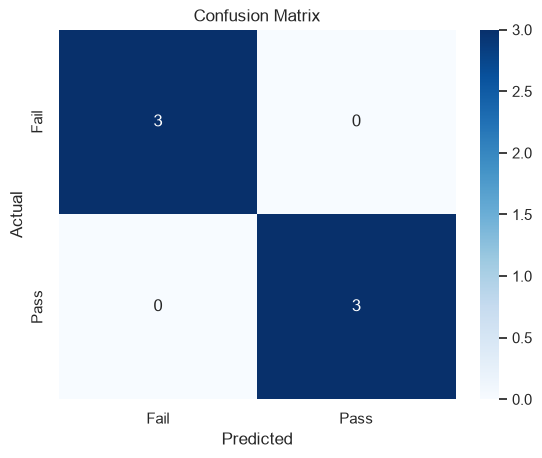

----Print Your Result----
Prediction based on your input: you likly to Pass


c:\Users\satyw\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#Step1 Load and Understand data
df = pd.read_csv('students_performance.csv')
print('Sample Rows\n',df.head())
print(f'Rows: {df.shape[0]} Columns: {df.shape[1]}')
print('Dataset Info')
print(df.info())
print(f'\nMissing value: \n{df.isnull().sum()}')

print('\nStatistics Summary\n',df.describe(include='all'))

#Step2 Prepocessing
le = LabelEncoder()
df['internet'] = le.fit_transform(df['internet'])
df['passed'] = le.fit_transform(df['passed'])
print(df.head())

#Step3 Feature Scaling
features = ['study_hours','attendance','past_score','sleeping_hours']
scaler = StandardScaler()
scaled_df = df.copy()
scaled_df[features] = scaler.fit_transform(df[features])
print(scaled_df.head())

#Step4 Spliting the Data
X = scaled_df[features]  # features
y = scaled_df['passed']  # target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#Step5 Train model
model = LogisticRegression()
model.fit(X_train,y_train)

#Step6 Make Prediction
y_pred = model.predict(X_test)

#Step7 Evaluate the Model
print('\nClassification Report')
print(classification_report(y_test, y_pred))

#Step8 Visualize Result
conf_matrix = confusion_matrix(y_test, y_pred)  

sns.set_theme()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Step9 Experiment
print('----Print Your Result----')
try:
    study_hours = float(input("Enter your study hours"))
    attendance = float(input("Enter your attendance"))
    past_score = float(input("Enter your past_score"))
    sleeping_hours = float(input("Enter your sleeping hours"))

    user_input_df = pd.DataFrame([{
        'study_hours': study_hours,
        'attendance': attendance,
        'past_score': past_score,
        'sleeping_hours': sleeping_hours
    }])

    scaled_user_input = scaler.transform(user_input_df)
    prediction = model.predict(scaled_user_input)[0]

    result = 'Pass' if prediction==1 else "Fail"
    print(f"Prediction based on your input: you likly to {result}")
except Exception as e:
    print('An error occur', e)  


